In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import json
import matplotlib
import matplotlib.pyplot as plt

In [23]:
%matplotlib inline

In [6]:
df = pd.read_csv("training_dataset.csv")

# not to be used as inputs
power_cols = ["total_watts", "w_big", "w_little", "w_gpu", "w_mem"]

feature_cols = [c for c in df.columns if c not in power_cols]

temp_cols = ["temp4", "temp5", "temp6", "temp7", "temp_gpu"]

targets = ["temp4", "temp5", "temp6", "temp7"]

print("Using feature columns:", feature_cols)
print("DF Shape:", df.shape)

Using feature columns: ['usage_c4', 'usage_c5', 'usage_c6', 'usage_c7', 'temp4', 'temp5', 'temp6', 'temp7', 'temp_gpu', 'freq_big_cluster']
DF Shape: (5415, 15)


In [7]:
models_info = {}

X_all = df[feature_cols].copy()
if "freq_big_cluster" in X_all.columns:
    X_all["freq_big_cluster"] = X_all["freq_big_cluster"] / 1e9

In [38]:
for target in targets:
    print(f"\nTraining model for target: {target}")

    y = df[target].shift(-1)

    valid_idx = y.dropna().index
    X = X_all.loc[valid_idx].reset_index(drop=True)
    y = y.loc[valid_idx].reset_index(drop=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    non_temp_features = [c for c in X.columns if c not in temp_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("scale", StandardScaler(), non_temp_features),
            ("pass", "passthrough", [c for c in X.columns if c in temp_cols])
        ]
    )

    mlp = MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu',
                       solver='adam', max_iter=500, random_state=42,
                       early_stopping=True)

    pipeline = make_pipeline(preprocessor, mlp)

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Test MSE: {mse:.4f}, R2: {r2:.4f}")

    models_info[target] = {"mse": float(mse), "r2": float(r2), "model": pipeline}


Training model for target: temp4
Test MSE: 0.1808, R2: 0.9970

Training model for target: temp5
Test MSE: 0.1168, R2: 0.9986

Training model for target: temp6
Test MSE: 0.2542, R2: 0.9972

Training model for target: temp7
Test MSE: 0.0694, R2: 0.9988


In [39]:
def evaluate_on_test(csv_path, models_info, plot_name):
    df_test = pd.read_csv(csv_path)
    X_test = df_test[feature_cols].copy()
    if "freq_big_cluster" in X_test.columns:
        X_test["freq_big_cluster"] = X_test["freq_big_cluster"] / 1e9

    results = {}
    # print(targets)
    for t in targets:
        model = models_info[t]["model"]

        y_true = df_test[t].shift(-1).dropna().reset_index(drop=True)
        X_pred = X_test.loc[: len(y_true)-1].reset_index(drop=True)

        y_pred = model.predict(X_pred)

        mse = mean_squared_error(y_true, y_pred)
        results[t] = {"mse": float(mse)}

        print(f"{t} MSE: {mse:.4f}")

        if t == 'temp4':
            time = np.arange(len(y_true))  
            plt.figure(figsize=(8,3))
            plt.plot(time, y_true, label='true')
            plt.plot(time, y_pred, label='pred')
            plt.xlabel('time [s]')
            plt.ylabel('temp4')
            plt.title(f"{plot_name} temp4: true vs pred")
            plt.legend()
            plt.tight_layout()

    return results

temp4 MSE: 0.3106
temp5 MSE: 1.4564
temp6 MSE: 0.2587
temp7 MSE: 0.1484
temp4 MSE: 1.3606
temp5 MSE: 2.4175
temp6 MSE: 1.2013
temp7 MSE: 0.6737
Blackscholes
 {'temp4': {'mse': 0.3105854635601422}, 'temp5': {'mse': 1.4564003411933475}, 'temp6': {'mse': 0.2587018033197089}, 'temp7': {'mse': 0.14841502451534952}}
Bodytrack
 {'temp4': {'mse': 1.36060996499447}, 'temp5': {'mse': 2.4175449567592633}, 'temp6': {'mse': 1.2013144102917825}, 'temp7': {'mse': 0.6737395496604982}}


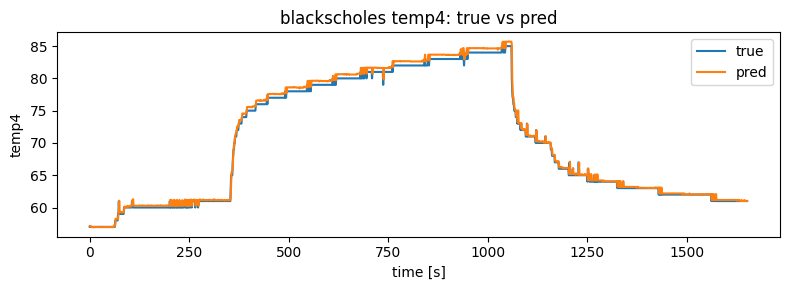

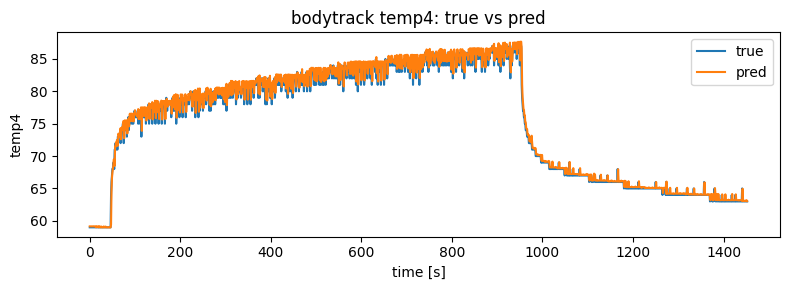

In [40]:
black_res = evaluate_on_test('testing_blackscholes.csv', models_info, 'blackscholes')
body_res = evaluate_on_test('testing_bodytrack.csv', models_info, 'bodytrack')

print("Blackscholes\n", black_res)
print("Bodytrack\n", body_res)